In [1]:
from sklearn.decomposition import PCA
import torch

## PCA reduction of Phoneme Output

We reverse the final output layer's weights. Instead of:

hidden (256) -> phonemes (50)

We take the phonemes and produce a 256-dimensional vector
representing each phoneme. Then we reduce to 3 dimensions using PCA.

In [2]:
from data_sb import make_encoders

# Recreate our encoder so we can put labels on the graph
hparams = {
    "word_outputs": 8000,
    "phone_outputs": 51,
    "supported_languages": ["fr", "en"],
    "word_files": {"fr": "data/words_fr.csv", "en": "data/words_en.csv"},
    "phon_files": {"fr": "data/phonemes_fr.csv", "en": "data/phonemes_en.csv"},
}
make_encoders(hparams)
phone_encoder = hparams["phon_encoder"]

In [3]:
def reduce_pca(model_file, phone_encoder, pca_components=3, normalize=True):
    """Takes a model file and produces a mapping from phoneme -> PCA components"""

    # Load model file and create phoneme -> hidden mapping, ignoring first "unk" token
    state_dict = torch.load(model_file, map_location="cpu")
    phone_mapping = state_dict["phone_out.weight"][1:]

    if normalize:
        phone_mapping = phone_mapping / phone_mapping.norm(dim=1, keepdim=True)

    # Reduce dimensions
    phone_pca = PCA(pca_components).fit_transform(phone_mapping)

    # Load labels and attach to component vectors
    phones = list(phone_encoder.lab2ind)[1:]
    phone2pca = {p: pca for p, pca in zip(phones, phone_pca)}

    return phone2pca

In [4]:
# Put everything together to generate phone2pca mapping
model_file = "bilingual_networks/results/bilingual_12345/save/CKPT+2025-11-10+02-23-13+00/model.ckpt"
phone2pca = reduce_pca(model_file, phone_encoder)

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize
def plot_phones(phone2pca):
    
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(projection='3d')

    matrix = np.array(list(phone2pca.values()))
    xs = matrix[:, 0]
    ys = matrix[:, 1]
    zs = matrix[:, 2]
    
    ax.scatter(xs, ys, zs)

    for i, txt in enumerate(phone2pca):
        ax.text(xs[i], ys[i], zs[i], txt, color='red')

    plt.show()

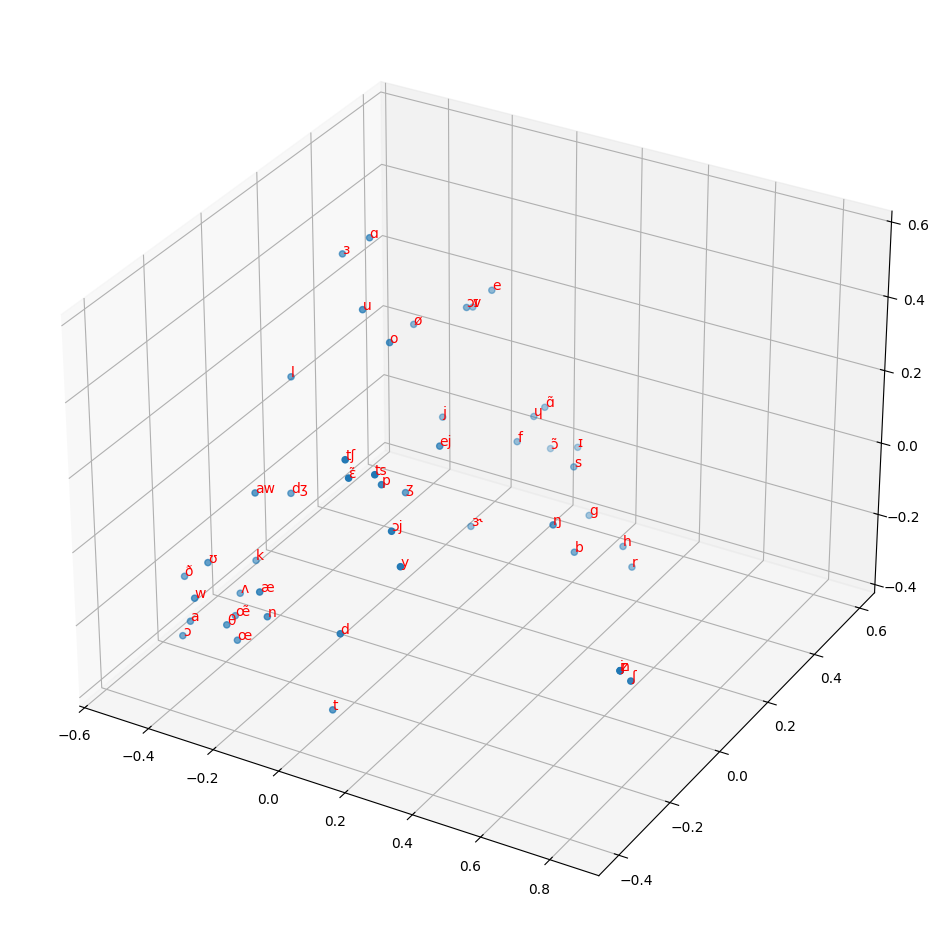

In [6]:
plot_phones(phone2pca)

In [7]:
phone2pca

{'h': array([ 0.35787826,  0.39710101, -0.27597286]),
 'd': array([ 0.13217695, -0.40330587, -0.05905899]),
 'ɑ̃': array([ 0.02537651,  0.51199376, -0.03995531]),
 'ʃ': array([ 0.8187665 , -0.19705691, -0.12946763]),
 'j': array([-0.14641575,  0.32265301,  0.00222135]),
 'ɛ̃': array([ 0.15545682, -0.39295098,  0.35235619]),
 'u': array([-0.15450945,  0.03461911,  0.46195438]),
 'θ': array([-0.29657508, -0.30863145, -0.21796955]),
 'r': array([ 0.40457632,  0.37181746, -0.30570819]),
 'i': array([ 0.8409548 , -0.27004485, -0.04596557]),
 'dʒ': array([-0.30125038, -0.06429827, -0.01272436]),
 't': array([ 0.02991911, -0.3148041 , -0.35644203]),
 'v': array([-0.18584476,  0.49230537,  0.20007014]),
 'ɪ': array([ 0.07829127,  0.57991814, -0.18127051]),
 'ʊ': array([-0.37797857, -0.27690275, -0.08944803]),
 'g': array([ 0.18974492,  0.48152508, -0.28599665]),
 'ɔɪ': array([-0.11124703,  0.3734489 ,  0.28480704]),
 'ʌ': array([-0.38677266, -0.15746147, -0.25426285]),
 'tʃ': array([ 0.1123652